In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = str(Path.cwd().parent)
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
    
import pandas as pd
import numpy as np

import joblib
from pathlib import Path
from src.config import add_borough_dummies 
from src.config import NON_RESIDENTIAL_NTAS, LOWER_MODEL_PATH, UPPER_MODEL_PATH, DATA_RAW

pd.set_option("display.max_columns", 120)

DATA_DIR = Path("../data")
MODEL_DIR = Path("../models")
OUT_DIR = Path("../data/processed")

OUT_DIR.mkdir(parents=True, exist_ok=True)


In [3]:
df = pd.read_csv(DATA_RAW)

print("Total NTAs:", len(df))
print("Missing rent:", df["median_monthly_rent"].isna().sum())
df.head()


Total NTAs: 260
Missing rent: 85


,nta2020,ntaname,num_bbls,avg_unitsres,avg_unitstotal,avg_yearbuilt,avg_market_value,num_properties,school_count,avg_ats,murder,rape,robbery,felony_assault,burglary,grand_larceny,grand_larceny_auto,total_violations,buildings_with_violations,violations_per_building,rent_impairing_violations,pct_rent_impairing,rent_num_properties,avg_monthly_rent,median_monthly_rent
0,QN8191,Flushing Meadows-Corona Park,31,0.000000,0.129032,442.806452,5.577701e+03,36.487311,NaN,NaN,0.595083,17.759920,185.886253,263.831372,92.675146,383.097319,118.814453,14.0,1.0,14.0000,0.0,0.0000,NaN,NaN,NaN
1,QN0601,Rego Park,2583,5.470770,5.953930,1906.347658,7.774261e+05,4704.243264,NaN,NaN,0.225370,3.490564,20.929933,34.290739,32.218593,89.470923,34.229803,10802.0,323.0,33.4427,610.0,0.0565,28.0,1902.657064,1869.060588
2,BK1204,Mapleton-Midwood (West),5143,2.547540,2.723702,1904.803228,8.090730e+05,6279.703180,NaN,NaN,0.976761,4.217520,32.988229,64.446533,41.426248,147.547358,66.761663,26663.0,933.0,28.5777,1366.0,0.0512,13.0,3324.565056,2444.750000
3,BX0702,Bedford Park,1309,17.839572,18.310924,1835.779985,1.097847e+06,1385.907912,NaN,NaN,2.108588,11.711685,117.391944,206.040030,55.494601,238.921371,89.940230,143154.0,847.0,169.0130,9345.0,0.0653,6.0,1946.530777,1529.090556
4,BK1771,Holy Cross Cemetery,1,0.000000,0.000000,1917.000000,8.039164e+01,1.038566,NaN,NaN,0.364676,2.051302,11.259369,36.649930,7.794948,27.760955,8.205208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
model = joblib.load(MODEL_DIR / "03_final_model.joblib")
model


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a fe

In [5]:
CRIME_COLS = [
    "murder", "rape", "robbery", "felony_assault",
    "burglary", "grand_larceny", "grand_larceny_auto"
]

def add_crime_rates(df, per=1000):
    total_units = df["avg_unitstotal"] * df["num_bbls"]
    total_units = total_units.replace(0, np.nan)  # avoid dividing by zero
    for c in CRIME_COLS:
        df[f"{c}_rate"] = df[c] / (total_units / per)
    return df

df = add_crime_rates(df)
df[[f"{c}_rate" for c in CRIME_COLS]].describe()

df = add_borough_dummies(df)
df["borough"].value_counts()

borough
QN    83
BK    68
BX    49
MN    38
SI    22
Name: count, dtype: int64

In [6]:
TARGET = "log_median_rent"

EXCLUDE_COLS = [
    "nta2020",
    "ntaname",
    "median_monthly_rent",
    "avg_monthly_rent",
    "rent_num_properties",
    "school_count",
    "avg_ats",
    "borough",
    TARGET,
    *CRIME_COLS
]

feature_cols = [c for c in df.columns if c not in EXCLUDE_COLS]

X = df[feature_cols].apply(pd.to_numeric, errors="coerce")

# Drop all-NaN columns (safety, should match File 03)
all_nan_cols = X.columns[X.isna().all()].tolist()
if all_nan_cols:
    print("Dropping all-NaN columns:", all_nan_cols)
    X = X.drop(columns=all_nan_cols)

feature_cols = X.columns.tolist()
print("Using", len(feature_cols), "features")


Using 22 features


In [7]:
df["pred_log_median_rent"] = model.predict(X)
df["pred_median_rent"] = np.exp(df["pred_log_median_rent"])

lower_model = joblib.load(LOWER_MODEL_PATH)
upper_model = joblib.load(UPPER_MODEL_PATH)
df["pred_low_median_rent"] = np.exp(lower_model.predict(X))
df["pred_high_median_rent"] = np.exp(upper_model.predict(X))

In [8]:
df = df[~df["nta2020"].isin(NON_RESIDENTIAL_NTAS)].copy()

final_output = df[[
    "nta2020", "ntaname", "borough", "median_monthly_rent",
    "pred_median_rent", "pred_low_median_rent", "pred_high_median_rent",
    "pct_rent_impairing", "grand_larceny_auto_rate", "avg_market_value"
]].copy()

final_output["rent_source"] = np.where(
    final_output["median_monthly_rent"].notna(),
    "actual",
    "predicted"
)

final_output.sort_values("pred_median_rent", ascending=False).head(10)

,nta2020,ntaname,borough,median_monthly_rent,pred_median_rent,pred_low_median_rent,pred_high_median_rent,pct_rent_impairing,grand_larceny_auto_rate,avg_market_value,rent_source
70,MN0102,Tribeca-Civic Center,MN,8318.054167,5920.952637,2033.621099,6894.718942,0.0864,0.805087,1.015334e+08,actual
258,MN0501,Midtown South-Flatiron-Union Square,MN,6582.995370,5827.300293,2104.869367,6810.069721,0.1018,0.638986,1.125405e+09,actual
129,MN0401,Chelsea-Hudson Yards,MN,6789.289338,5568.732422,2139.217644,6791.624850,0.0936,0.716430,8.626081e+06,actual
248,MN0802,Upper East Side-Carnegie Hill,MN,6688.144330,5546.466797,2133.172098,6655.218413,0.0809,0.749781,8.180636e+06,actual
208,MN0502,Midtown-Times Square,MN,4948.192857,5373.948730,2007.412608,4380.341185,0.0835,0.873839,2.281293e+09,actual
18,MN0602,Gramercy,MN,5674.062865,4989.124023,2102.447773,5668.631008,0.1009,0.539288,2.433258e+06,actual
243,MN0101,Financial District-Battery Park City,MN,5062.363095,4924.476074,2167.210889,6530.809894,0.1012,0.483644,3.500340e+08,actual
62,MN0201,SoHo-Little Italy-Hudson Square,MN,7439.869919,4922.776367,2054.515770,6067.761354,0.1010,0.596324,3.858275e+06,actual
56,MN0203,West Village,MN,4660.375571,4590.864746,1985.575597,5539.736525,0.0823,0.488403,4.199123e+06,actual
94,MN0202,Greenwich Village,MN,5320.868056,4579.474121,2077.385294,6095.809508,0.0892,0.511675,2.609666e+06,actual


In [9]:
# Count check
print(final_output["rent_source"].value_counts())

# Are the predictions reasonable?
print(final_output["pred_median_rent"].describe())


rent_source
actual       175
predicted     41
Name: count, dtype: int64
count     216.000000
mean     2274.272705
std       875.985107
min      1057.349976
25%      1756.394104
50%      2048.155212
75%      2391.913757
max      5920.952637
Name: pred_median_rent, dtype: float64


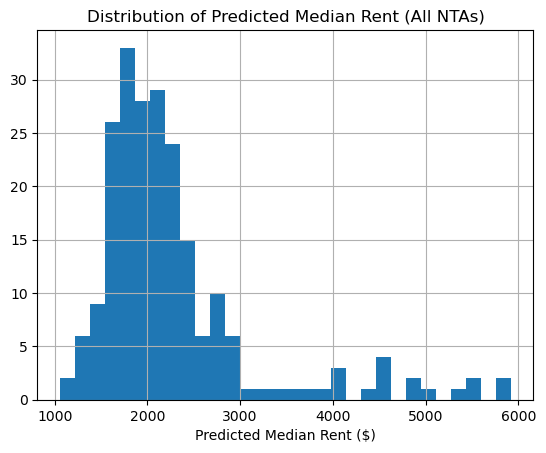

In [10]:
import matplotlib.pyplot as plt

final_output["pred_median_rent"].hist(bins=30)
plt.title("Distribution of Predicted Median Rent (All NTAs)")
plt.xlabel("Predicted Median Rent ($)")
plt.show()


In [11]:
final_output.to_csv(OUT_DIR / "04_final_nta_rent_predictions.csv", index=False)

print("Saved:",
      OUT_DIR / "04_final_nta_rent_predictions.csv")


Saved: ../data/processed/04_final_nta_rent_predictions.csv


Before finalizing predictions for the unlabeled NTAs, a sanity check: are all 85 unlabeled NTAs genuinely under-reported residential neighborhoods, or could some be non-residential land where a rent prediction wouldn't be meaningful?

In [12]:
raw = pd.read_csv(DATA_RAW)
raw = add_crime_rates(raw)
suspect = raw[raw["grand_larceny_auto_rate"] > 1000]  
print(suspect[["nta2020", "ntaname", "avg_unitstotal", "num_bbls", "num_properties", "avg_market_value"]])

    nta2020                                            ntaname  \
0    QN8191                       Flushing Meadows-Corona Park   
5    BK1892                                     McGuire Fields   
7    SI9593                                   Great Kills Park   
9    SI0291                            Freshkills Park (North)   
23   BX1271                                  Woodlawn Cemetery   
32   BX0492                                     Claremont Park   
38   QN8491                                 Jamaica Bay (East)   
41   BX1071                                        Hart Island   
49   QN0271                    Calvary & Mount Zion Cemeteries   
50   QN0871              Mount Hebron & Cedar Grove Cemeteries   
66   MN1191                                   Randall's Island   
78   QN1191                                    Alley Pond Park   
83   MN0191  The Battery-Governors Island-Ellis Island-Libe...   
84   MN1291                                    Highbridge Park   
85   QN079

Confirms 44 of the 85 unlabeled NTAs are parks, cemeteries, airports, and similar non-residential land (identifiable by near-zero housing unit counts, which also explains why their crime-rate features are erratic, see notebook 03). These are excluded from the final predicted output in 02_predict.py